In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pybaselines import Baseline, utils
from scipy.optimize import curve_fit
from sklearn.metrics import auc
from scipy.stats import linregress
from scipy.signal import  peak_widths

In [ ]:
path = "/Users/verityjanerothermelsmith/Downloads/CuGeGaS4/"
files = [file for file in os.listdir(path) if  file.endswith('.txt')]
dfs=[]
for file in sorted(files): 
    df = pd.read_csv(file, sep='\t', names=["eV", "intensity"])
    #print(file)
    #display(df)
    dfs.append(df[(df["eV"] >= 1.2) & (df["eV"] <= 2.1)])
power_list= [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.,  1.1, 1.2, 1.3, 1.4]


In [ ]:


power_legend= [str(s)+" mW" for s in power_list]


['0.1mW', '0.2mW', '0.3mW', '0.4mW', '0.5mW', '0.6mW', '0.7mW', '0.8mW', '0.9mW', '1.0mW', '1.1mW', '1.2mW', '1.3mW', '1.4mW']


In [15]:
for index, df in enumerate(dfs):
    x= df["eV"]
    y= df["intensity"]
    baseline_fitter = Baseline(x_data=x)
    bkg_1, params_1 = baseline_fitter.modpoly(y, poly_order=1)
    df["intensity-bkg"] = y - bkg_1

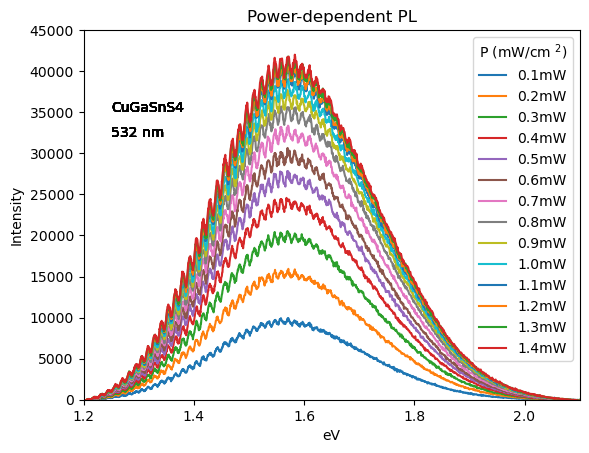

In [127]:
for index, df in enumerate(dfs):
    x= df["eV"]
    y= df["intensity"]
    title="Power-dependent PL"
    y_corrected= df["intensity-bkg"]
    #plt.plot(x, y, label='raw data', lw=1.5)
    #plt.plot(x, bkg_1, '--', label='modpoly')
    plt.plot(x, y_corrected, '-', label=power_legend[index])
    plt.ylabel("Intensity")
    plt.xlabel("eV")
    plt.ylim(0, 45000)
    plt.xlim(1.2, 2.1)
    plt.text(1.25, 35000, "CuGaSnS4", fontsize=10)
    plt.text(1.25, 32000, "532 nm ", fontsize=10)
    plt.title(title)
    plt.legend(title="P (mW/cm $^2$)")
plt.show()

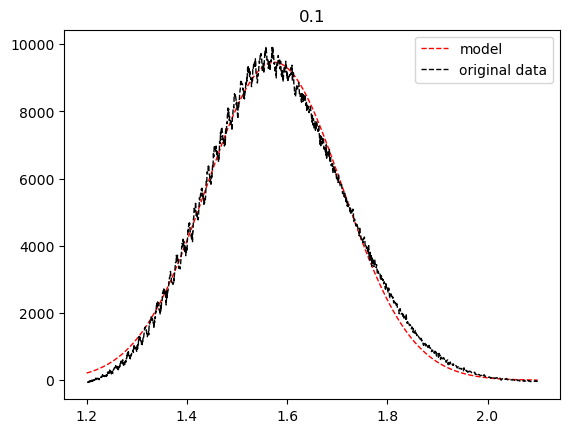

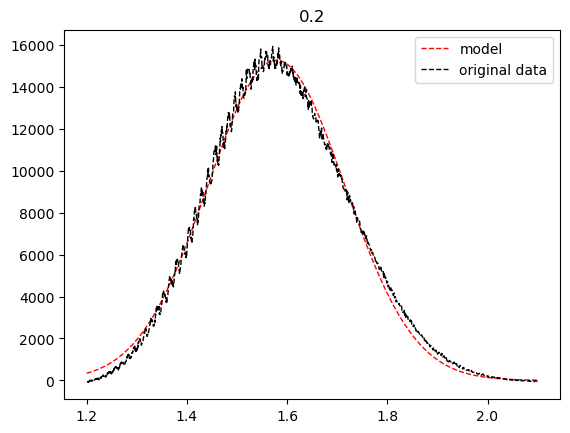

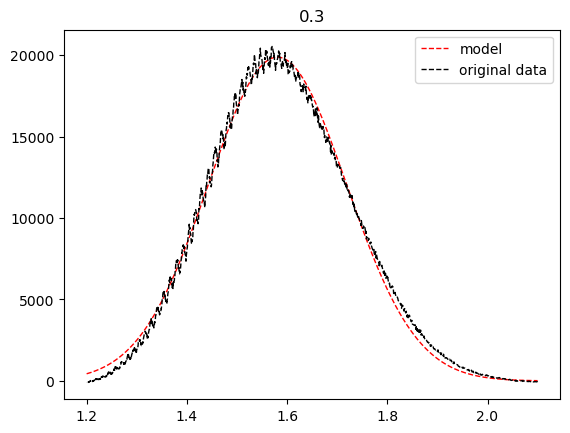

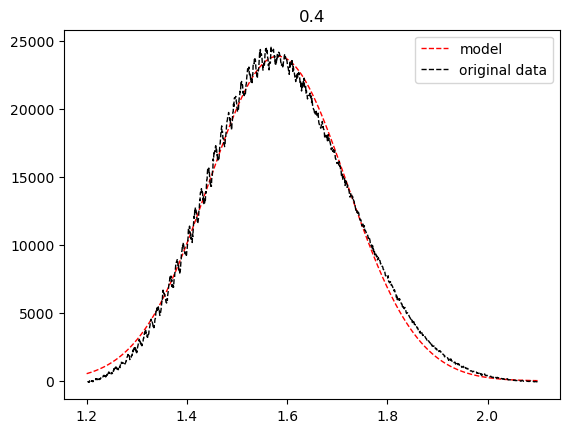

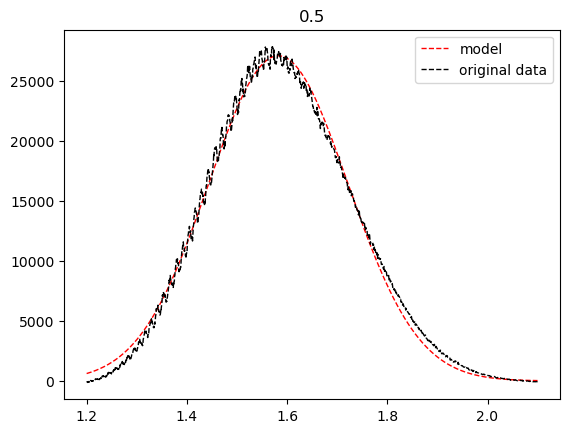

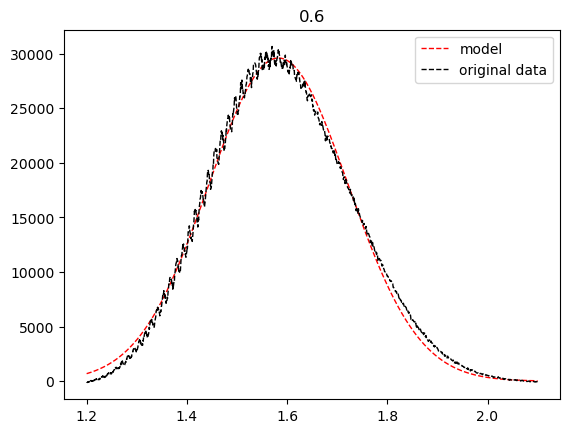

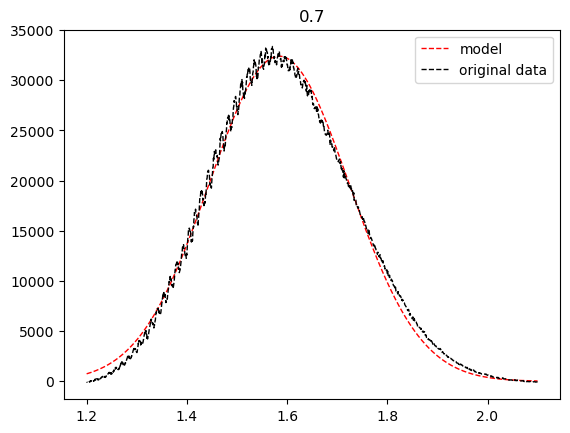

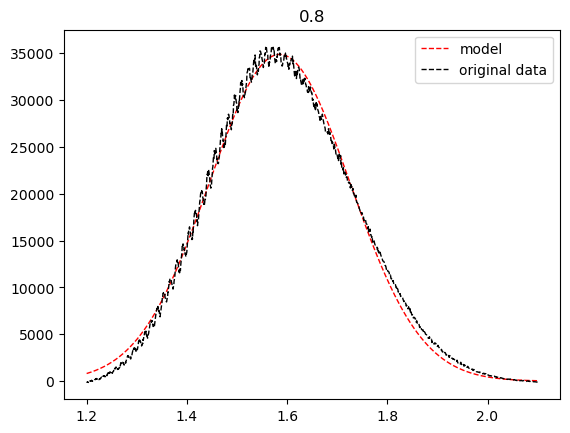

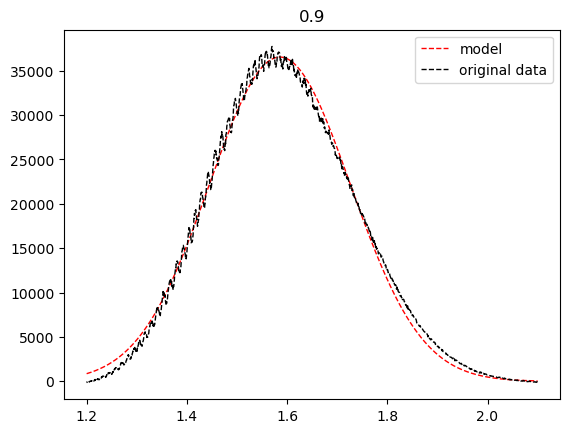

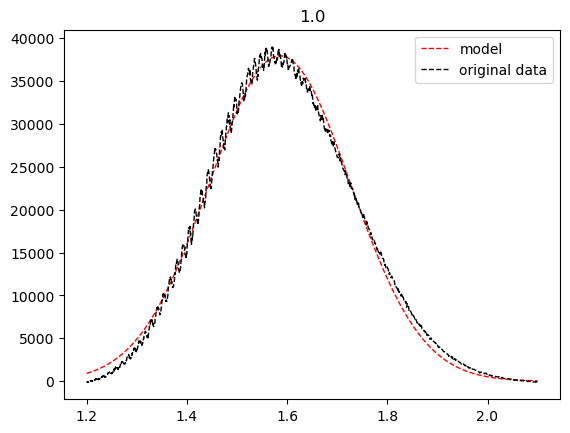

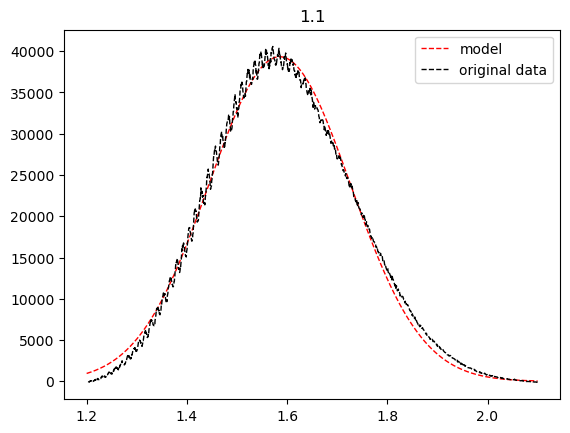

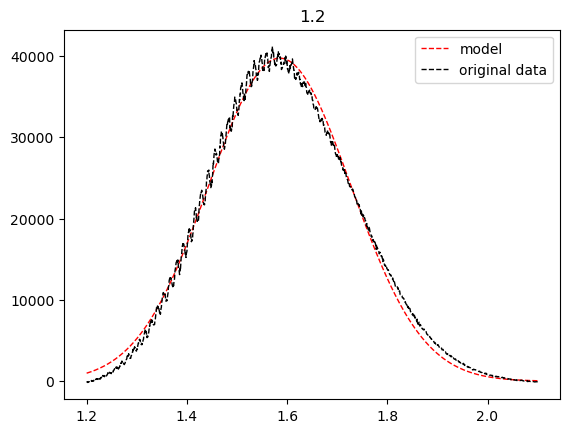

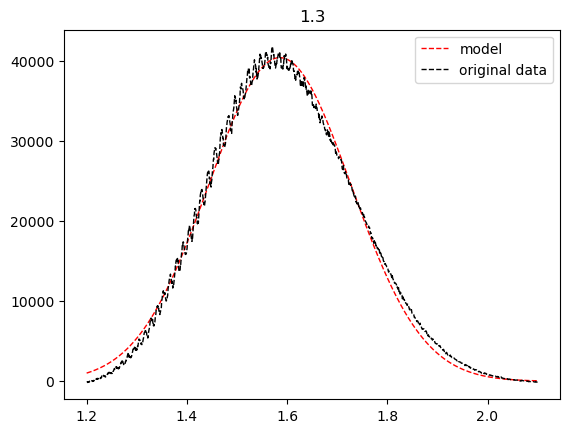

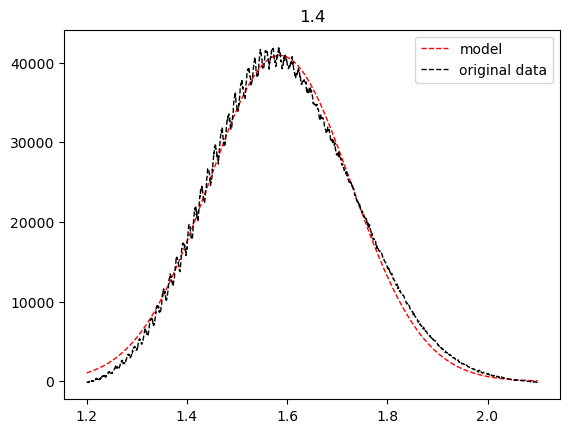

In [17]:
#x, y inputs can be lists or 1D numpy arrays

def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/2/sigma**2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def fit(x, y, power):
    params, cov = curve_fit(gauss, x, y, (1.6, .2, 20000)) 
    sigma=np.sqrt(np.diag(cov))
    x_fit = np.linspace(x.min(), x.max(), 500)
    #plot combined...
    #plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
    #...and individual Gauss curves
    peak_1= gauss(x_fit, *params[:3])
    plt.plot(x_fit, peak_1, color='red', lw=1, ls="--", label='model')

    #area under curve
    peak_1_auc  = auc(x_fit, peak_1)



    #and the original data points if no histogram has been created before
    plt.plot(x, y, color="black", lw=1,ls="--",  label="original data")
    plt.legend()
    plt.title(power)

    
    params_df_1= pd.DataFrame(data={'params': params, 'sigma': sigma}, index=gauss.__code__.co_varnames[1:])


    fwhm_1_1 = params[0] - (2.355/2) * params[1]
    fwhm_1_2 = params[0] + (2.355/2) * params[1]



    plt.show() 
    return params_df_1, peak_1_auc, fwhm_1_1, fwhm_1_2

expected_list=[(1.6, .2, 20000, 1.8, .2, 40000),(1.6, .2, 20000, 1.8, .2, 40000),(1.6, .2, 20000, 1.8, .2, 40000), 
               (1.6, .2, 20000, 1.8, .2, 40000), (1.6, .2, 15000, 1.8, .2, 35000),(1.6, .2, 15000, 1.8, .2, 35000),
               (1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 15000, 1.8, .2, 35000),
               (1.6, .2, 15000, 1.8, .2, 35000),(1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 20000, 1.8, .2, 35000),
               (1.6, .2, 20000, 1.8, .2, 35000)]

peak_1_auc= []
peak_1_fwhm_1 = []
peak_1_fwhm_2 = []
params_peak_1= []



for index, df in enumerate(dfs):
    y = df["intensity-bkg"]
    x= df["eV"]
    power= power_list[index]
    

    params_df_1, peak_1, fwhm_1_1, fwhm_1_2  = fit(x, y, power) 

    peak_1_auc.append(peak_1)
    params_peak_1.append(params_df_1)
    peak_1_fwhm_1.append(fwhm_1_1)
    peak_1_fwhm_2 .append(fwhm_1_2)
    

    


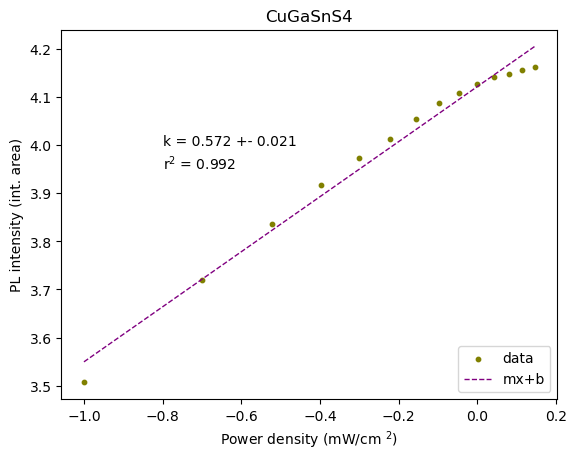

LinregressResult(slope=np.float64(0.5720960483419234), intercept=np.float64(4.121497996364482), rvalue=np.float64(0.9921813219832367), pvalue=np.float64(3.2434295574898003e-12), stderr=np.float64(0.020773916142263486), intercept_stderr=np.float64(0.008118081714712668))


In [95]:
log_x = np.log10(power_list)
log_y= np.log10(peak_1_auc)

res = linregress(log_x, log_y) 
y_pred= res.slope * log_x + res.intercept

plt.scatter(log_x, log_y, marker='o', color='olive', s=10, label='data')
plt.plot(log_x, y_pred, color='purple', lw=1, ls="--", label='mx+b')
plt.legend(loc='lower right')
plt.xlabel("Power density (mW/cm $^2$)")
plt.ylabel("PL intensity (int. area)")
plt.text(-.8, 4, 'k = 0.572 +- 0.021', fontsize=10)
plt.text(-.8, 3.95, 'r$^2$ = 0.992', fontsize=10)
# plt.xscale('log')
# plt.yscale('log')
plt.title("CuGaSnS4")
plt.show()

print(res)

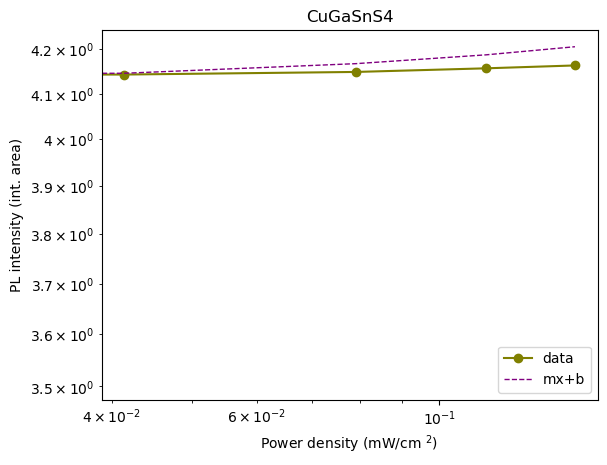

LinregressResult(slope=np.float64(0.5720960483419234), intercept=np.float64(4.121497996364482), rvalue=np.float64(0.9921813219832367), pvalue=np.float64(3.2434295574898003e-12), stderr=np.float64(0.020773916142263486), intercept_stderr=np.float64(0.008118081714712668))


In [102]:
log_x = np.log10(power_list)
log_y= np.log10(peak_1_auc)

res = linregress(log_x, log_y) 
y_pred= res.slope * log_x + res.intercept

plt.plot(log_x, log_y, marker='o', color='olive', label='data')
plt.plot(log_x, y_pred, color='purple', lw=1, ls="--", label='mx+b')
plt.legend(loc='lower right')
plt.xlabel("Power density (mW/cm $^2$)")
plt.ylabel("PL intensity (int. area)")
#plt.text(-.8, 4, 'k = 0.572 +- 0.021', fontsize=10)
#plt.text(-.8, 3.95, 'r$^2$ = 0.992', fontsize=10)
plt.xscale('log')
plt.yscale('log')

plt.title("CuGaSnS4")
plt.show()

print(res)